## Monte Carlo Simulation

A very common tool in physics is a so called **Monte Carlo Simulation (MCS)**. We want to carry out a MCS in order to estimate the number $\pi$ (even though this is not the most efficient way to do so).

The idea is to generate uniformly distributed random numbers from 0 to 1 for two coordinates $x$ and $y$. We then select those numbers $N$ which satisfy the condition $x^2 + y^2 < 1$ and compare $N$ to the total number $N_{tot}$ of generated random numbers.<br>
For large $N_{tot}$<br> 
<br>
$N \propto \pi/4\,\, r^2$ and<br> 
$N_{tot} \propto \, r^2$<br>
<br>
where $r = 1$ since we only pick random numbers from 0 to 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def CalcPi(N):
    X = np.random.uniform(0,1,(N,1))
    Y = np.random.uniform(0,1,(N,1))
    R = X**2 + Y**2
    PI = 4*(R<1).sum()/N
    
    print(f"Pi = {PI: 0.6f}")

    xplot = np.arange(0,1,1/1000)
    yplot = np.sqrt(1 - xplot**2)
    
    plt.plot(xplot, yplot, 'r--')
    plt.fill_between(xplot, yplot, facecolor = 'k', alpha = 0.12)
    plt.scatter(X[np.argwhere(R>1)],Y[np.argwhere(R>1)], s = 1, c = 'k')
    plt.scatter(X[np.argwhere(R<1)],Y[np.argwhere(R<1)], s = 1, c = 'b')
    plt.show()

Let us run ```CalcPi``` for different $N$ and see how close it gets to the actual value of $\pi$:

Pi =  3.137016


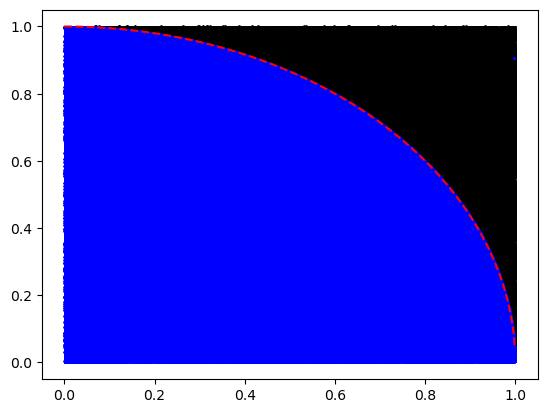

In [5]:
CalcPi(500000)

Now, we want to modify ```CalcPi``` so that we can run it many times (>100) for different $N = 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000$. How does the average value of $\pi$ and its error change as a function of $N$?

In [40]:
def CalcPi2(N):
    Nreps = 1000
    PI    = np.zeros((Nreps)) 

    for i in range(Nreps):
    
        X     = np.random.uniform(0,1,(N,1))
        Y     = np.random.uniform(0,1,(N,1))
        R     = X**2 + Y**2
        PI[i] = 4*(R< 1).sum()/N

    return np.mean(PI), np.std(PI)

In [48]:
CalcPi2(50)

(3.1404800000000006, 0.23453053020875556)

Now for many different $N$:

In [50]:
N = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]

In [52]:
AllPi = np.array(list(map(CalcPi2,N)))

In [54]:
print(AllPi)

[[3.1304     0.53482319]
 [3.1382     0.37478095]
 [3.14232    0.2357376 ]
 [3.14504    0.16151346]
 [3.13912    0.11018178]
 [3.141672   0.07337458]
 [3.14398    0.05150332]
 [3.142268   0.03730598]
 [3.141572   0.02359427]
 [3.1415716  0.0162218 ]
 [3.1413274  0.01161353]]


<br>

Plotting $\pi$ vs $N$:

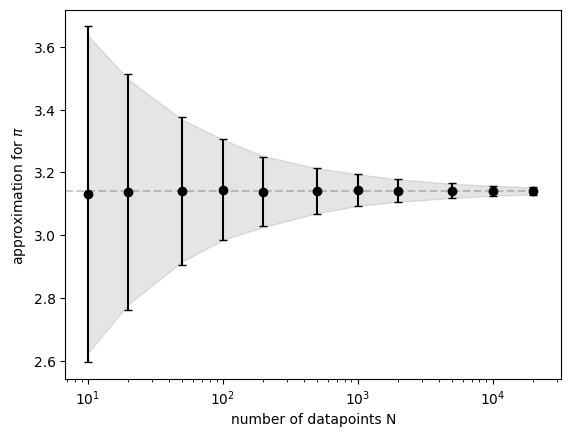

In [56]:
e_theo = 4*0.4/np.sqrt(np.array(N))

plt.fill_between(N, AllPi[:,0] + e_theo, AllPi[:,0] - e_theo, color = 'k', alpha = 0.1, interpolate = True,)
plt.plot([0, 1.1*N[-1]], [np.pi, np.pi], 'k--', alpha = 0.2)
plt.errorbar(N, AllPi[:,0], yerr=AllPi[:,1], capsize=3, fmt="ko", ecolor = "black")
plt.xscale('log')
plt.xlabel('number of datapoints N')
plt.ylabel('approximation for $\pi$')
plt.show()

The above Monte-Carlo-Method is called "hit or miss" and is actually the **least efficient** way to calculate $\pi$. We could also interprete the circle as a function $y = \sqrt{1-x^2}$ which we need to integrate from $x_1=0$ to $x_2=1$, i. e.<br>

$\int_0^1 \sqrt{1-x^2} dx = \frac{\pi}{4}$

In order to run a more efficient Monte-Carlo-Method, we can use the fact, that the average of a quantity approaches the expected value (or mean) for large sample size $N$ and we also know that an integral is just a sum for infinitly small $\Delta x$. Hence, putting it all together we find that

$\mu_y = \int_a^b y(x)\,p(x)\,dx = \frac{1}{b-a}\,\int_a^b \sqrt{1-x^2} dx$ (for $p(x)$ is uniform)<br>
<br>
$\mu_y \approx \frac{1}{N}\sum_{i=1}^N y_i(x_i)$

And therefore (if $a=0$ and $b=1$)

$\int_a^b \sqrt{1-x^2} dx = \frac{\pi}{4} \approx \frac{b-a}{N}\sum_{i=1}^N y_i(x_i)$<br>

we only need to evaluate $y_i$ and calculate the average, multiplied by the size of the interval we are drawing $x$ from. Using this relation, we can write a code that is shorter and faster. 

In [6]:
def MCS_Pi_numpy_Trad(n_samples: int = 10000) -> None:
    #three lines!!
    X  = np.random.uniform(0,1,(n_samples))
    Y  = np.sqrt(1 - X**2)
    
    PI = 4*np.mean(Y)
    
    print(f"Pi = {PI: 0.6f}")

In [7]:
MCS_Pi_numpy_Trad()

Pi =  3.141533
